In [7]:
!pip install kagglehub 

In [14]:
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))


In [15]:
print(df.columns)
columns_to_show = ['AvgSessionDurationMinutes', 'SessionsPerWeek', 'PlayerLevel', 'PlayTimeHours', 'InGamePurchases', 'AchievementsUnlocked']
summary_table = df[columns_to_show].describe().T.round(0)
summary_table = summary_table.astype(int)
summary_table


Index(['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours',
       'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek',
       'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked',
       'EngagementLevel'],
      dtype='object')


,count,mean,std,min,25%,50%,75%,max
AvgSessionDurationMinutes,40034,95,49,10,52,95,137,179
SessionsPerWeek,40034,9,6,0,4,9,14,19
PlayerLevel,40034,50,29,1,25,49,74,99
PlayTimeHours,40034,12,7,0,6,12,18,24
InGamePurchases,40034,0,0,0,0,0,0,1
AchievementsUnlocked,40034,25,14,0,12,25,37,49


In [46]:
X = df.drop(['PlayerID', 'EngagementLevel'], axis=1)
y = df['EngagementLevel']

le = LabelEncoder()
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

Overall Model Accuracy: 91.02%

Detailed Classification Report:
              precision    recall  f1-score   support

         Low       0.92      0.87      0.90      2035
      Medium       0.91      0.88      0.89      2093
        High       0.90      0.95      0.93      3879

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007



All column currently name： ['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel']


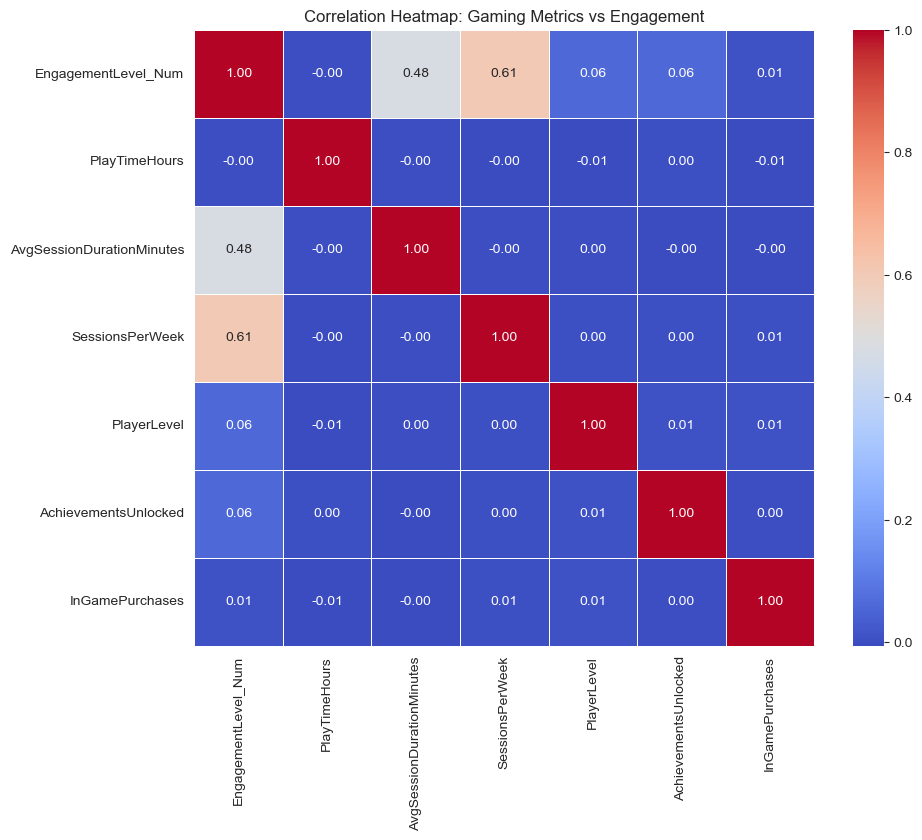

In [47]:
df.columns = df.columns.str.strip()
print("All column currently name：", df.columns.tolist())

df_corr = df.copy()

if 'EngagementLevel' in df_corr.columns:
    # Check if this column is already numeric (if it is, mapping is unnecessary)
    if df_corr['EngagementLevel'].dtype == 'object':
        mapping = {'Low': 0, 'Medium': 1, 'High': 2}
        df_corr['EngagementLevel_Num'] = df_corr['EngagementLevel'].map(mapping)
    else:
        # If already numeric, create a direct copy
        df_corr['EngagementLevel_Num'] = df_corr['EngagementLevel']
else:
    print("Error: EngagementLevel column not found. Please check the print output above!")

# 3. Select columns (Ensure these column names exist in your data)
# Note: EngagementLevel_Num is used here
cols = ['EngagementLevel_Num', 'PlayTimeHours', 'AvgSessionDurationMinutes', 
        'SessionsPerWeek', 'PlayerLevel', 'AchievementsUnlocked', 'InGamePurchases']

# Filter out columns that do not actually exist in the data to prevent errors
existing_cols = [c for c in cols if c in df_corr.columns]

# 4. Calculate correlation matrix and plot
correlation_matrix = df_corr[existing_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Gaming Metrics vs Engagement')
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

# 1. Clean column names (Prevents KeyError caused by hidden spaces)
data.columns = data.columns.str.strip()

# 2. Define the "core features" to keep (PlayerID is excluded, effectively removing it)
selected_columns = [
    'Age', 'Gender', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 
    'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 
    'AchievementsUnlocked', 'Location', 'EngagementLevel'
]

# 3. Extract data using .loc (Using your 'data' variable directly)
# If your variable is named 'data', do not use 'df'
df_final = data.loc[:, selected_columns].copy()

# 4. Convert data types (This step is necessary for the model to process the data)
df_final['EngagementLevel'] = df_final['EngagementLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_final['Gender'] = LabelEncoder().fit_transform(df_final['Gender'])
df_final = pd.get_dummies(df_final, columns=['Location', 'GameGenre'])

df_final.head(10)

,Age,Gender,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Location_Asia,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,43,1,16.271119,0,6,108,79,25,1,False,False,True,False,False,False,False,False,True
1,29,0,5.525961,0,5,144,11,10,1,False,False,False,True,False,False,False,False,True
2,22,0,8.223755,0,16,142,35,41,2,False,False,False,True,False,False,False,True,False
3,35,1,5.265351,1,9,85,57,47,1,False,False,False,True,True,False,False,False,False
4,33,1,15.531945,0,2,131,95,37,1,False,True,False,False,True,False,False,False,False
5,37,1,20.561855,0,2,81,74,22,0,False,True,False,False,False,True,False,False,False
6,25,1,9.752716,0,1,50,13,2,0,False,False,False,True,True,False,False,False,False
7,25,0,4.401729,0,10,48,27,23,1,True,False,False,False,False,True,False,False,False
8,38,0,18.152733,0,5,101,23,41,1,False,True,False,False,False,False,True,False,False
9,38,0,23.942772,0,13,95,99,36,2,False,False,True,False,False,False,False,True,False


In [25]:
# 1. Use the test set to make predictions
y_pred = rf_model.predict(X_test)

# 2. Generate the report and convert it to a DataFrame format
report_dict = classification_report(y_test, y_pred, output_dict=True, target_names=['Low', 'Medium', 'High'])
report_df = pd.DataFrame(report_dict).transpose()

# 3. Format the table (Round to 2 decimal places for better readability)
report_df = report_df.round(2)
print("--- Model Prediction Performance Evaluation Table ---")
print(report_df)

--- Model Prediction Performance Evaluation Table ---
              precision  recall  f1-score  support
Low                0.91    0.86      0.89   2093.0
Medium             0.89    0.95      0.92   3879.0
High               0.92    0.86      0.89   2035.0
accuracy           0.90    0.90      0.90      0.9
macro avg          0.91    0.89      0.90   8007.0
weighted avg       0.90    0.90      0.90   8007.0


In [27]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importance_summary = feature_importance_df.head(10).round(3)

print("--- Feature Importance ---")
print(feature_importance_summary)

--- Feature Importance ---
                     Feature  Importance
0            SessionsPerWeek       0.420
1  AvgSessionDurationMinutes       0.289
2              PlayTimeHours       0.062
3                PlayerLevel       0.059
4       AchievementsUnlocked       0.056
5                        Age       0.046
6                     Gender       0.009
7            InGamePurchases       0.007
8               Location_USA       0.007
9            Location_Europe       0.006


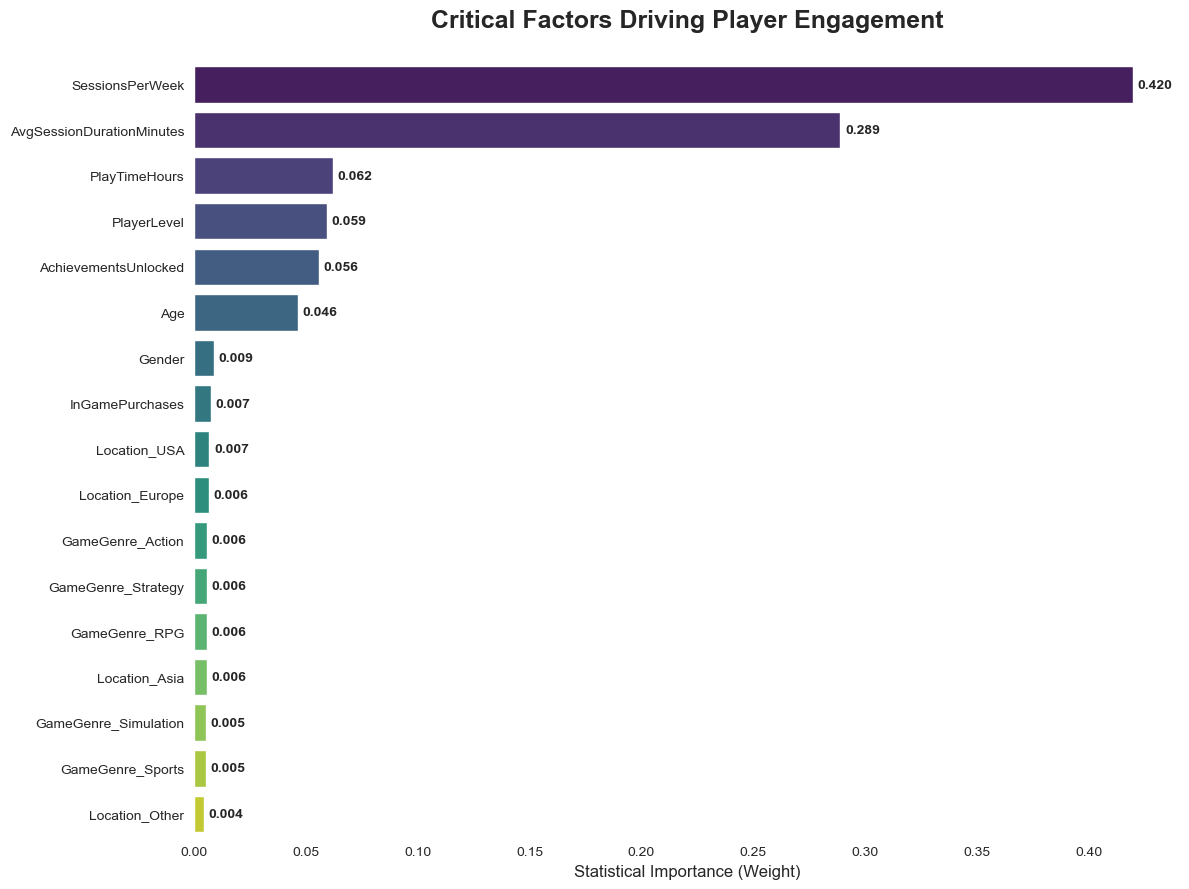

In [28]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- 2. Plot Aesthetics ---
plt.figure(figsize=(12, 9)) # Slightly taller to prevent text crowding
sns.set_style("white") 

# Using the viridis gradient for a high-end professional look
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# --- 3. Add Precise Value Labels (The "Soul" of the chart) ---
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.002,  # Slight offset to the right
            p.get_y() + p.get_height()/2, 
            f'{width:.3f}', 
            va='center', fontsize=10, fontweight='bold')

# --- 4. Title and Detail Optimization ---
plt.title('Critical Factors Driving Player Engagement', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Statistical Importance (Weight)', fontsize=12)
plt.ylabel('') # Hide Y-axis label to keep the visual clean
sns.despine(left=True, bottom=True) # Remove the outer frame

plt.tight_layout()
plt.show()

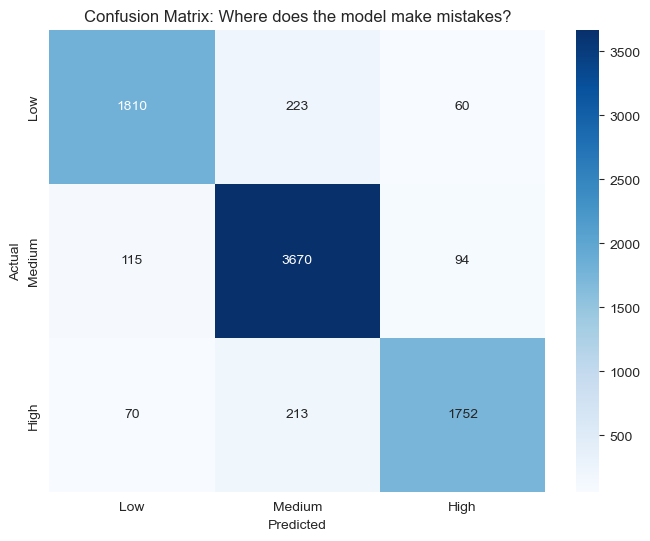

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Where does the model make mistakes?')
plt.show()

In [30]:
probabilities = rf_model.predict_proba(X_test[:5])
prob_df = pd.DataFrame(probabilities, columns=['Low_Prob', 'Medium_Prob', 'High_Prob'])
print(prob_df)

   Low_Prob  Medium_Prob  High_Prob
0      0.04         0.87       0.09
1      0.08         0.82       0.10
2      0.74         0.20       0.06
3      0.04         0.89       0.07
4      0.05         0.78       0.17


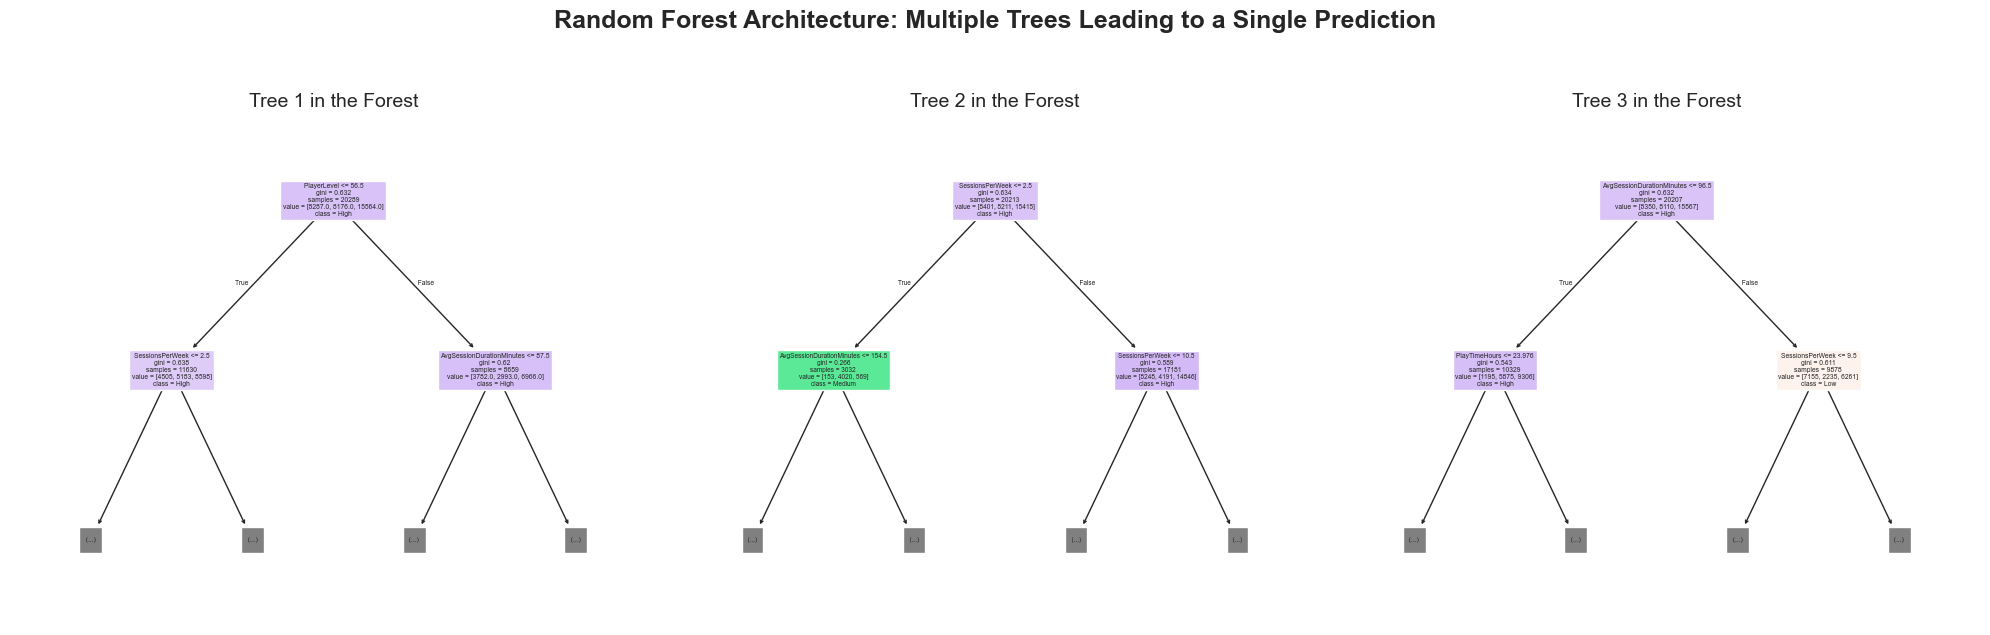

Total trees in your forest: 100
Final Prediction = Majority Vote (Mode) across all these trees.


In [44]:
import matplotlib.pyplot as plt

# 1. Setup the figure to show the 'Forest' concept
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# 2. Visualize the first 3 trees to represent the 'Ensemble' (Bagging)
# This mimics the 'Decision Trees' row in your reference image
for i in range(3):
    plot_tree(rf_model.estimators_[i], 
              feature_names=X.columns, 
              class_names=['Low', 'Medium', 'High'], 
              filled=True, 
              max_depth=1, # Keep it simple to show the structure
              ax=axes[i])
    axes[i].set_title(f'Tree {i+1} in the Forest', fontsize=14)

# 3. Add an overall title describing the Bagging/Averaging process
plt.suptitle('Random Forest Architecture: Multiple Trees Leading to a Single Prediction', 
             fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

# 4. Print the final 'Logic' of your forest
print(f"Total trees in your forest: {rf_model.n_estimators}")
print("Final Prediction = Majority Vote (Mode) across all these trees.")